In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RAW_CSV = "./output/analysis/dates_sencitivite_minput_BS.csv"
OUT_DIR = "./output/summary/"

Z_95 = 1.96  # для 95% CI по среднему
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


In [3]:
df = pd.read_csv(RAW_CSV)

# Приводим числовые колонки
num_cols = [
    "price", "duration", "time_path_gen", "comp_time",
    "delta", "gamma", "theta", "rho", "vega",
    "nb_paths", "nb_dates", "spot", "strike", "maturity",
    "volatility", "drift", "dividend", "nb_stocks"
]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Фильтр: только строки, где есть price (успешные прогоны)
df = df.dropna(subset=["price"]).copy()

# В идеале должно быть 3 algo * 4 nb_dates * 20 runs = 240 строк
print("Rows:", len(df))
display(df.head(5))
print("\nAlgos:", sorted(df["algo"].unique()))
print("nb_dates:", sorted(df["nb_dates"].dropna().unique()))


Rows: 240


,algo,model,payoff,drift,volatility,mean,speed,correlation,hurst,nb_stocks,nb_paths,nb_dates,spot,strike,dividend,maturity,nb_epochs,hidden_size,factors,ridge_coeff,use_payoff_as_input,train_ITM_only,use_path,price,duration,time_path_gen,comp_time,delta,gamma,theta,rho,vega,greeks_method,price_upper_bound
0,LSM,BlackScholes,MinPut,0.05,0.2,0.01,2,-0.3,0.75,1,20000,10,100,100,0.0,1.0,30,50,"(1.0, 1.0, 1.0)",1.0,True,True,False,6.078010,0.561499,0.202012,0.359487,-0.397896,0.022498,-2.206142,-31.429664,37.776283,regression,NaN
1,LSM,BlackScholes,MinPut,0.05,0.2,0.01,2,-0.3,0.75,1,20000,10,100,100,0.0,1.0,30,50,"(1.0, 1.0, 1.0)",1.0,True,True,False,6.117382,0.519770,0.195819,0.323951,-0.438378,0.023432,-2.188604,-30.316119,37.044127,regression,NaN
2,LSM,BlackScholes,MinPut,0.05,0.2,0.01,2,-0.3,0.75,1,20000,10,100,100,0.0,1.0,30,50,"(1.0, 1.0, 1.0)",1.0,True,True,False,6.135989,0.461196,0.180904,0.280292,-0.404074,0.022612,-2.195217,-31.815617,37.860007,regression,NaN
3,LSM,BlackScholes,MinPut,0.05,0.2,0.01,2,-0.3,0.75,1,20000,10,100,100,0.0,1.0,30,50,"(1.0, 1.0, 1.0)",1.0,True,True,False,5.939429,0.520618,0.227890,0.292728,-0.406931,0.022455,-2.159401,-30.972590,37.080330,regression,NaN
4,LSM,BlackScholes,MinPut,0.05,0.2,0.01,2,-0.3,0.75,1,20000,10,100,100,0.0,1.0,30,50,"(1.0, 1.0, 1.0)",1.0,True,True,False,6.181345,0.554454,0.228684,0.325770,-0.409143,0.022773,-2.199849,-33.316793,38.656921,regression,NaN



Algos: ['LSM', 'NLSM', 'RLSM']
nb_dates: [10, 25, 50, 100]


In [ ]:
# Проверим, что параметры едины (кроме nb_dates)
# algo,model,payoff,drift,volatility,mean,speed,correlation,hurst,nb_stocks,nb_paths,nb_dates,spot,strike,dividend,maturity,nb_epochs,hidden_size,factors,ridge_coeff,use_payoff_as_input,train_ITM_only,use_path,price,duration,time_path_gen,comp_time,delta,gamma,theta,rho,vega,greeks_method,price_upper_bound

key_cols = ["model", "payoff", "spot", "strike", "maturity", "volatility", "drift", "dividend", "nb_paths", "nb_stocks"]
profile = df[key_cols].drop_duplicates()
print("Unique scenario profiles (should be small):", len(profile))
display(profile)

# Проверим, есть ли delta
delta_missing = df["delta"].isna().mean() if "delta" in df.columns else 1.0
print("Share of missing delta:", delta_missing)

# Сколько прогонов на (algo, nb_dates)
counts = df.groupby(["algo", "nb_dates"]).size().unstack(fill_value=0)
display(counts)


Unique scenario profiles (should be small): 1


,model,payoff,spot,strike,maturity,volatility,drift,dividend,nb_paths,nb_stocks
0,BlackScholes,MinPut,100,100,1.0,0.2,0.05,0.0,20000,1


Share of missing delta: 0.0


nb_dates,10,25,50,100
algo,,,,
LSM,20,20,20,20
NLSM,20,20,20,20
RLSM,20,20,20,20


In [15]:
df["delta"].isna().mean()

0.0

In [ ]:
group_cols = ["algo", "nb_dates"]

def summarize_group(g: pd.DataFrame) -> pd.Series:
    n = len(g)

    price_mean = g["price"].mean()
    price_std = g["price"].std(ddof=1) if n > 1 else 0.0
    price_se = price_std / np.sqrt(n) if n > 0 else np.nan
    price_ci_half = Z_95 * price_se

    duration_mean = g["duration"].mean()
    duration_std = g["duration"].std(ddof=1) if n > 1 else 0.0

    time_path_gen_mean = g["time_path_gen"].mean() if "time_path_gen" in g.columns else np.nan
    comp_time_mean = g["comp_time"].mean() if "comp_time" in g.columns else np.nan

    delta_mean = g["delta"].mean() if "delta" in g.columns else np.nan
    delta_std = g["delta"].std(ddof=1) if ("delta" in g.columns and n > 1) else np.nan

    return pd.Series({
        "n_runs": n,
        "price_mean": price_mean,
        "price_ci95_half": price_ci_half,
        "price_ci95_low": price_mean - price_ci_half,
        "price_ci95_high": price_mean + price_ci_half,
        "duration_mean": duration_mean,
        "duration_std": duration_std,
        "time_path_gen_mean": time_path_gen_mean,
        "comp_time_mean": comp_time_mean,
        "delta_mean": delta_mean,
        "delta_std": delta_std,
    })

pricing_summary = df.groupby(group_cols, dropna=False).apply(summarize_group).reset_index()
pricing_summary = pricing_summary.sort_values(["nb_dates", "algo"]).reset_index(drop=True)

display(pricing_summary)

out_path = os.path.join(OUT_DIR, "18_01_pricing_summary_by_nb_dates.csv")
pricing_summary.to_csv(out_path, index=False)
print("Saved:", out_path)


,algo,nb_dates,n_runs,price_mean,price_ci95_half,price_ci95_low,price_ci95_high,duration_mean,duration_std,time_path_gen_mean,comp_time_mean,delta_mean,delta_std
0,LSM,10,20.0,6.048912,0.032831,6.016081,6.081743,0.581488,0.062378,0.224277,0.357211,-0.420625,0.014363
1,NLSM,10,20.0,6.021774,0.023297,5.998477,6.045070,8.832284,0.491925,0.078534,8.753750,-0.417542,0.011179
2,RLSM,10,20.0,6.103908,0.026364,6.077544,6.130272,3.614647,0.071634,0.164487,3.450161,-0.421759,0.009818
3,LSM,25,20.0,6.005607,0.031085,5.974522,6.036691,1.242097,0.099453,0.430491,0.811606,-0.424068,0.009629
4,NLSM,25,20.0,6.049095,0.031905,6.017191,6.081000,23.704377,2.100793,0.195770,23.508607,-0.420088,0.007685
5,RLSM,25,20.0,6.139525,0.029734,6.109791,6.169260,9.544790,0.255514,0.361238,9.183552,-0.421062,0.009143
6,LSM,50,20.0,6.050858,0.030394,6.020465,6.081252,2.234445,0.125799,0.612141,1.622304,-0.420713,0.010176
7,NLSM,50,20.0,6.046732,0.027878,6.018854,6.074610,46.850355,2.862134,0.351620,46.498735,-0.416972,0.009422
8,RLSM,50,20.0,6.145976,0.024076,6.121900,6.170053,19.388610,0.229163,0.538468,18.850141,-0.430970,0.010066
9,LSM,100,20.0,6.061832,0.023274,6.038558,6.085106,4.182711,0.211412,0.975030,3.207681,-0.421168,0.011114


Saved: ./output/summary/pricing_summary_by_nb_dates.csv


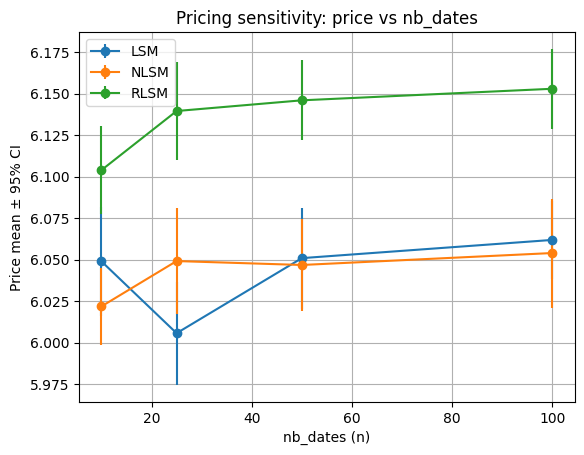

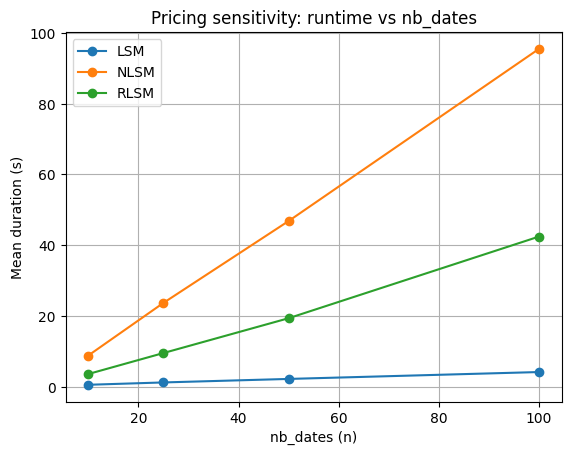

In [23]:
# Price vs nb_dates with CI half-width
plt.figure()
for algo in sorted(pricing_summary["algo"].unique()):
    sub = pricing_summary[pricing_summary["algo"] == algo].sort_values("nb_dates")
    plt.errorbar(sub["nb_dates"], sub["price_mean"], yerr=sub["price_ci95_half"], marker="o", linestyle="-", label=algo)

plt.xlabel("nb_dates (n)")
plt.ylabel("Price mean ± 95% CI")
plt.title("Pricing sensitivity: price vs nb_dates")
plt.legend()
plt.grid(True)
plt.show()

# Duration vs nb_dates
plt.figure()
for algo in sorted(pricing_summary["algo"].unique()):
    sub = pricing_summary[pricing_summary["algo"] == algo].sort_values("nb_dates")
    plt.plot(sub["nb_dates"], sub["duration_mean"], marker="o", linestyle="-", label=algo)

plt.xlabel("nb_dates (n)")
plt.ylabel("Mean duration (s)")
plt.title("Pricing sensitivity: runtime vs nb_dates")
plt.legend()
plt.grid(True)
plt.show()


Симулятор BS траекторий + расчёт shortfall L

In [4]:
def simulate_bs_paths(S0: float, r: float, sigma: float, T: float, n_steps: int, n_paths: int, seed: int = 0):
    """
    Возвращает S: shape (n_paths, n_steps+1) с S[:,0]=S0
    """
    local_rng = np.random.default_rng(seed)
    dt = T / n_steps
    Z = local_rng.standard_normal(size=(n_paths, n_steps))
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    logS = np.cumsum(increments, axis=1)
    S = np.empty((n_paths, n_steps + 1), dtype=float)
    S[:, 0] = S0
    S[:, 1:] = S0 * np.exp(logS)
    return S

def shortfall_buy_and_hold(S: np.ndarray, K: float, r: float, T: float, V0: float, delta0: float):
    """
    S shape (M, n+1)
    buy-and-hold: держим delta0 с t=0 до T
    X_{i} = (V0 - delta0*S0)*exp(r*t_i) + delta0*S_i
    L = max_i discounted( payoff_i - X_i )
    payoff_i = (K - S_i)^+
    """
    M, n_plus1 = S.shape
    n = n_plus1 - 1
    dt = T / n
    t = np.arange(0, n_plus1) * dt  # 0..T

    S0 = S[:, 0]
    cash0 = V0 - delta0 * S0  # остаток в кэше при открытии

    X = cash0[:, None] * np.exp(r * t[None, :]) + delta0 * S  # портфель на каждом шаге

    payoff = np.maximum(K - S, 0.0)

    discounted_gap = (payoff - X) * np.exp(-r * t[None, :])
    L = np.max(discounted_gap[:, 1:], axis=1)  # i=1..n, исключаем t=0
    return L


Расчёт VaR/CVaR по каждому (algo, nb_dates)

In [5]:
def var_cvar(samples: np.ndarray, alpha: float = 0.99):
    """
    VaR_alpha = quantile_alpha
    CVaR_alpha = mean of tail beyond VaR (worst alpha% tail)
    """
    samples = np.asarray(samples)
    q = np.quantile(samples, alpha)
    tail = samples[samples >= q]
    cvar = tail.mean() if len(tail) > 0 else q
    return q, cvar

ALPHA = 0.99

# Сколько траекторий для оценки хедж-риск распределения L
# (можно 20000, но для ноутбука часто разумнее 5000–10000)
M_HEDGE = 10000

risk_rows = []

# Берём по одному "run" как (V0, delta0) и строим L-распределение на новых путях
# Чтобы было устойчиво, можно агрегировать риск метрики по всем nb_runs (20)
for (algo, n_steps), g in df.groupby(["algo", "nb_dates"]):
    # фиксируем параметры сценария (одинаковы внутри группы)
    S0 = float(g["spot"].iloc[0])
    K = float(g["strike"].iloc[0])
    r = float(g["drift"].iloc[0])
    sigma = float(g["volatility"].iloc[0])
    T = float(g["maturity"].iloc[0])

    # Накапливаем VaR/CVaR по run’ам (каждый run даёт свою V0/delta0)
    vars_, cvars_, means_ = [], [], []
    for j, row in g.reset_index(drop=True).iterrows():
        V0 = float(row["price"])
        d0 = float(row["delta"]) if not np.isnan(row["delta"]) else 0.0

        S = simulate_bs_paths(S0, r, sigma, T, int(n_steps), M_HEDGE, seed=1000 + j)
        L = shortfall_buy_and_hold(S, K, r, T, V0, d0)

        v, cv = var_cvar(L, alpha=ALPHA)
        vars_.append(v)
        cvars_.append(cv)
        means_.append(L.mean())

    # summary по runs
    risk_rows.append({
        "algo": algo,
        "nb_dates": int(n_steps),
        "n_runs": len(g),
        "L_mean_mean": float(np.mean(means_)),
        "VaR_mean": float(np.mean(vars_)),
        "CVaR_mean": float(np.mean(cvars_)),
        "VaR_std_across_runs": float(np.std(vars_, ddof=1)) if len(vars_) > 1 else 0.0,
        "CVaR_std_across_runs": float(np.std(cvars_, ddof=1)) if len(cvars_) > 1 else 0.0,
    })

risk_summary = pd.DataFrame(risk_rows).sort_values(["nb_dates", "algo"]).reset_index(drop=True)
display(risk_summary)

out_path = os.path.join(OUT_DIR, f"hedge_risk_buyhold_alpha{ALPHA}.csv")
risk_summary.to_csv(out_path, index=False)
print("Saved:", out_path)


,algo,nb_dates,n_runs,L_mean_mean,VaR_mean,CVaR_mean,VaR_std_across_runs,CVaR_std_across_runs
0,LSM,10,20,3.003798,19.177780,23.424826,0.836658,1.145038
1,NLSM,10,20,3.024261,18.975706,23.235721,0.736849,0.897898
2,RLSM,10,20,2.950250,19.153102,23.433782,0.669351,0.851096
3,LSM,25,20,3.665397,19.929263,24.452132,0.639362,1.075463
4,NLSM,25,20,3.611280,19.697689,24.129348,0.574888,0.784474
5,RLSM,25,20,3.523882,19.638972,24.111283,0.674924,1.078957
6,LSM,50,20,3.930425,20.068253,24.554925,0.619738,0.936466
7,NLSM,50,20,3.925295,19.874377,24.295728,0.743780,1.085009
8,RLSM,50,20,3.861491,20.568444,25.187910,0.755295,0.898966
9,LSM,100,20,4.139962,20.346389,24.871403,0.800094,1.076455


Saved: ./output/summary/hedge_risk_buyhold_alpha0.99.csv


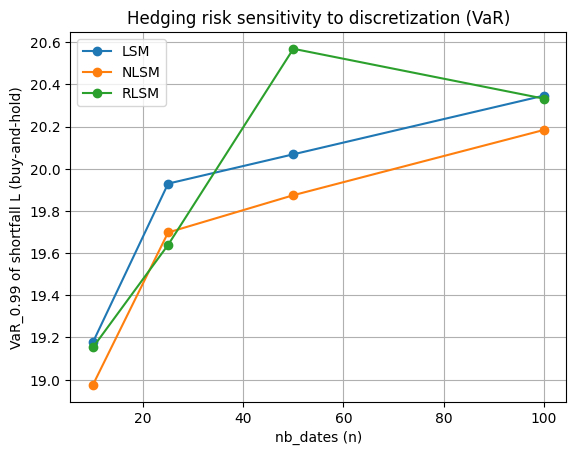

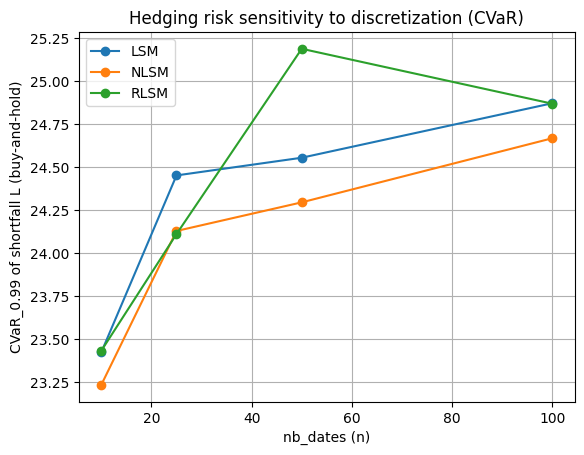

In [6]:
plt.figure()
for algo in sorted(risk_summary["algo"].unique()):
    sub = risk_summary[risk_summary["algo"] == algo].sort_values("nb_dates")
    plt.plot(sub["nb_dates"], sub["VaR_mean"], marker="o", linestyle="-", label=algo)

plt.xlabel("nb_dates (n)")
plt.ylabel(f"VaR_{ALPHA} of shortfall L (buy-and-hold)")
plt.title("Hedging risk sensitivity to discretization (VaR)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for algo in sorted(risk_summary["algo"].unique()):
    sub = risk_summary[risk_summary["algo"] == algo].sort_values("nb_dates")
    plt.plot(sub["nb_dates"], sub["CVaR_mean"], marker="o", linestyle="-", label=algo)

plt.xlabel("nb_dates (n)")
plt.ylabel(f"CVaR_{ALPHA} of shortfall L (buy-and-hold)")
plt.title("Hedging risk sensitivity to discretization (CVaR)")
plt.legend()
plt.grid(True)
plt.show()


Диагностика: распределения L для одного nb_dates

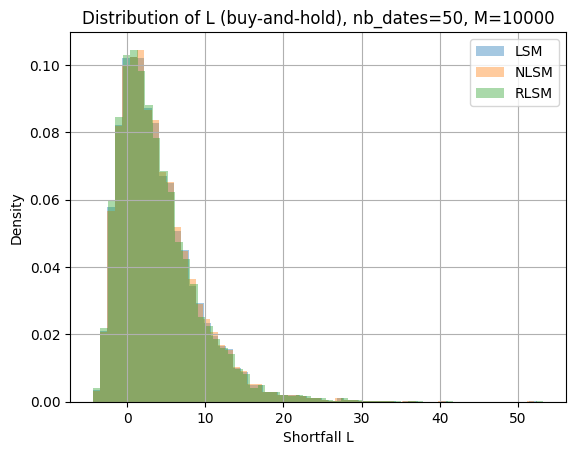

In [7]:
# Выбери nb_dates для сравнения хвостов
N_PICK = 50

sub = df[df["nb_dates"] == N_PICK].copy()
assert len(sub) > 0, f"No rows for nb_dates={N_PICK}"

plt.figure()
for algo in sorted(sub["algo"].unique()):
    # возьмём один representative run (или средний по V0/d0 — но проще один)
    row = sub[sub["algo"] == algo].iloc[0]

    S0 = float(row["spot"])
    K = float(row["strike"])
    r = float(row["drift"])
    sigma = float(row["volatility"])
    T = float(row["maturity"])
    V0 = float(row["price"])
    d0 = float(row["delta"]) if not np.isnan(row["delta"]) else 0.0

    S = simulate_bs_paths(S0, r, sigma, T, N_PICK, M_HEDGE, seed=999)
    L = shortfall_buy_and_hold(S, K, r, T, V0, d0)

    # плотность (гистограмма)
    plt.hist(L, bins=60, density=True, alpha=0.4, label=algo)

plt.xlabel("Shortfall L")
plt.ylabel("Density")
plt.title(f"Distribution of L (buy-and-hold), nb_dates={N_PICK}, M={M_HEDGE}")
plt.legend()
plt.grid(True)
plt.show()


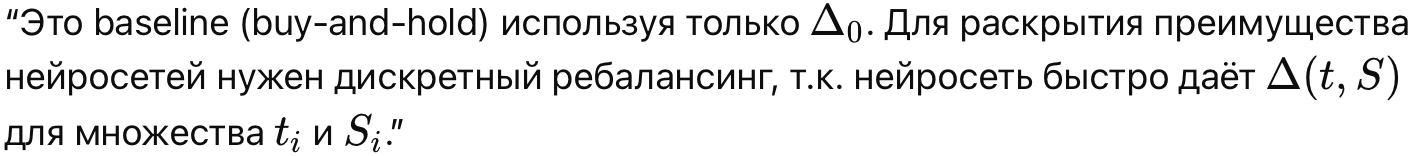

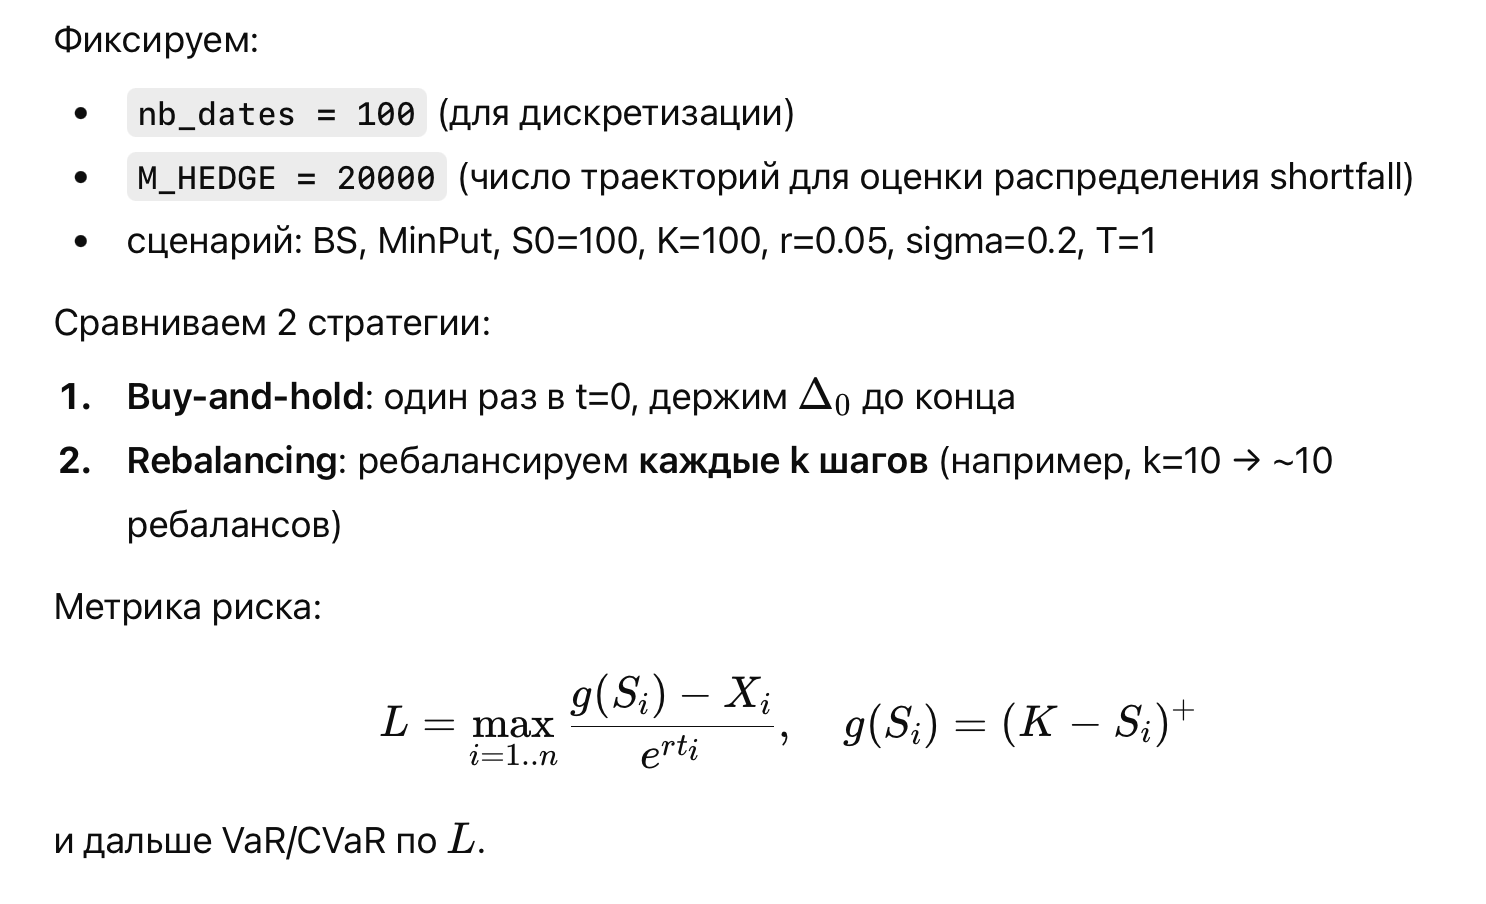

In [8]:
N_STEPS = 100          # nb_dates
REBAL_EVERY = 10       # ребаланс каждые 10 шагов => ~10 ребалансов
M_HEDGE = 20000        # число траекторий для оценки распределения shortfall
ALPHA = 0.99           # уровень риска для VaR/CVaR

# выбираем один "representative" run (V0, delta0) на каждый algo
# можно позже усреднить по 20 runs — но для "увидеть хедж" достаточно одного


In [9]:
def simulate_bs_paths(S0: float, r: float, sigma: float, T: float, n_steps: int, n_paths: int, seed: int = 0):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    Z = rng.standard_normal(size=(n_paths, n_steps))
    inc = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    logS = np.cumsum(inc, axis=1)
    S = np.empty((n_paths, n_steps + 1), dtype=float)
    S[:, 0] = S0
    S[:, 1:] = S0 * np.exp(logS)
    return S

def payoff_put(S, K):
    return np.maximum(K - S, 0.0)

def var_cvar(samples: np.ndarray, alpha: float = 0.99):
    q = np.quantile(samples, alpha)
    tail = samples[samples >= q]
    cvar = tail.mean() if len(tail) > 0 else q
    return float(q), float(cvar)


In [10]:
def shortfall_buy_and_hold(S: np.ndarray, K: float, r: float, T: float, V0: float, delta0: float):
    """
    S shape (M, n+1)
    X_t = cash*exp(rt) + delta0*S_t, cash = V0 - delta0*S0
    L = max_{i>=1} discounted( payoff_i - X_i )
    """
    M, n_plus1 = S.shape
    n = n_plus1 - 1
    dt = T / n
    t = np.arange(0, n_plus1) * dt
    
    cash0 = V0 - delta0 * S[:, 0]
    X = cash0[:, None] * np.exp(r * t[None, :]) + delta0 * S
    
    g = payoff_put(S, K)
    discounted_gap = (g - X) * np.exp(-r * t[None, :])
    L = np.max(discounted_gap[:, 1:], axis=1)
    return L


In [11]:
from math import log, sqrt, exp
from scipy.stats import norm

def bs_put_delta(S, K, r, sigma, tau):
    """
    Delta европейского put в BS:
    Δ_put = N(d1) - 1
    d1 = (ln(S/K) + (r + 0.5σ^2)τ) / (σ sqrt(τ))
    """
    S = np.asarray(S, dtype=float)
    tau = np.maximum(tau, 1e-12)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    return norm.cdf(d1) - 1.0

def shortfall_rebalance_bsdelta(S: np.ndarray, K: float, r: float, sigma: float, T: float, V0: float, rebalance_every: int):
    """
    Ребалансируем delta каждые rebalance_every шагов по BS-формуле (европейский put).
    Портфель самофинансируемый:
      cash_{t+dt} = cash_t * exp(r dt) - (Δ_{new}-Δ_{old}) * S_t
      X_t = cash_t + Δ_t * S_t
    L = max discounted( payoff - X )
    """
    M, n_plus1 = S.shape
    n = n_plus1 - 1
    dt = T / n
    times = np.arange(0, n_plus1) * dt

    # initial hedge at t=0
    tau0 = T - times[0]
    delta = bs_put_delta(S[:, 0], K, r, sigma, tau0)
    cash = V0 - delta * S[:, 0]  # self-financing initial
    
    # track X at all times
    X = np.empty((M, n_plus1), dtype=float)
    X[:, 0] = cash + delta * S[:, 0]

    for i in range(1, n_plus1):
        # accrue cash
        cash = cash * np.exp(r * dt)

        # rebalance schedule
        if (i % rebalance_every == 0) and (i < n_plus1):
            tau = T - times[i]
            new_delta = bs_put_delta(S[:, i], K, r, sigma, tau)
            # buy/sell underlying using cash: cash decreases if we buy more
            cash = cash - (new_delta - delta) * S[:, i]
            delta = new_delta

        X[:, i] = cash + delta * S[:, i]

    g = payoff_put(S, K)
    discounted_gap = (g - X) * np.exp(-r * times[None, :])
    L = np.max(discounted_gap[:, 1:], axis=1)
    return L


In [12]:
# Берём из df любую строку для N_STEPS и нужного сценария
# (у тебя в df есть algo, nb_dates, price, delta, spot, strike, drift, volatility, maturity)
sub = df[(df["nb_dates"] == N_STEPS)].copy()
assert len(sub) > 0, f"No rows with nb_dates={N_STEPS} in CSV"

# параметры сценария из первой строки
row0 = sub.iloc[0]
S0 = float(row0["spot"])
K  = float(row0["strike"])
r  = float(row0["drift"])
sigma = float(row0["volatility"])
T  = float(row0["maturity"])

# одна и та же выборка траекторий для честного сравнения
S = simulate_bs_paths(S0, r, sigma, T, N_STEPS, M_HEDGE, seed=123)

results = []

for algo in sorted(sub["algo"].unique()):
    # representative run (можно потом усреднить по 20)
    row = sub[sub["algo"] == algo].iloc[0]
    V0 = float(row["price"])
    d0 = float(row["delta"]) if not np.isnan(row["delta"]) else 0.0

    L_bh = shortfall_buy_and_hold(S, K, r, T, V0, d0)
    var_bh, cvar_bh = var_cvar(L_bh, alpha=ALPHA)

    # rebalancing by BS delta (baseline strategy)
    L_rb = shortfall_rebalance_bsdelta(S, K, r, sigma, T, V0, rebalance_every=REBAL_EVERY)
    var_rb, cvar_rb = var_cvar(L_rb, alpha=ALPHA)

    results.append({
        "algo": algo,
        "V0": V0,
        "delta0_from_csv": d0,
        f"VaR{ALPHA}_buyhold": var_bh,
        f"CVaR{ALPHA}_buyhold": cvar_bh,
        f"VaR{ALPHA}_rebalance": var_rb,
        f"CVaR{ALPHA}_rebalance": cvar_rb,
        "L_mean_buyhold": float(L_bh.mean()),
        "L_mean_rebalance": float(L_rb.mean()),
    })

risk_compare = pd.DataFrame(results)
display(risk_compare)

out_path = os.path.join(OUT_DIR, f"hedge_compare_buyhold_vs_rebalance_n{N_STEPS}_k{REBAL_EVERY}_alpha{ALPHA}.csv")
risk_compare.to_csv(out_path, index=False)
print("Saved:", out_path)


,algo,V0,delta0_from_csv,VaR0.99_buyhold,CVaR0.99_buyhold,VaR0.99_rebalance,CVaR0.99_rebalance,L_mean_buyhold,L_mean_rebalance
0,LSM,5.972796,-0.419244,20.611953,25.681069,6.250227,7.434735,4.184550,0.955444
1,NLSM,6.064423,-0.422291,20.712595,25.813078,6.158600,7.343108,4.100939,0.863818
2,RLSM,6.086388,-0.415299,20.248165,25.279271,6.136635,7.321143,4.060876,0.841853


Saved: ./output/summary/hedge_compare_buyhold_vs_rebalance_n100_k10_alpha0.99.csv


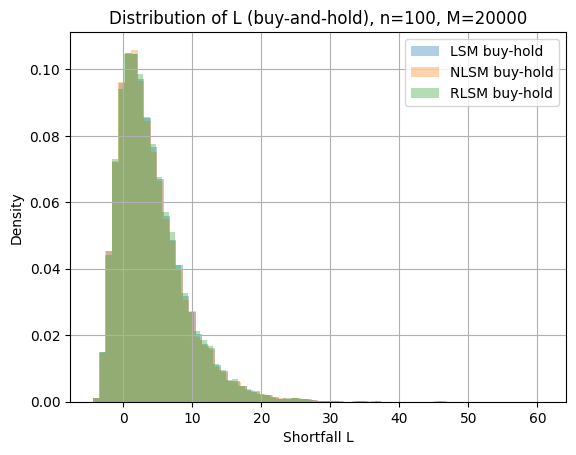

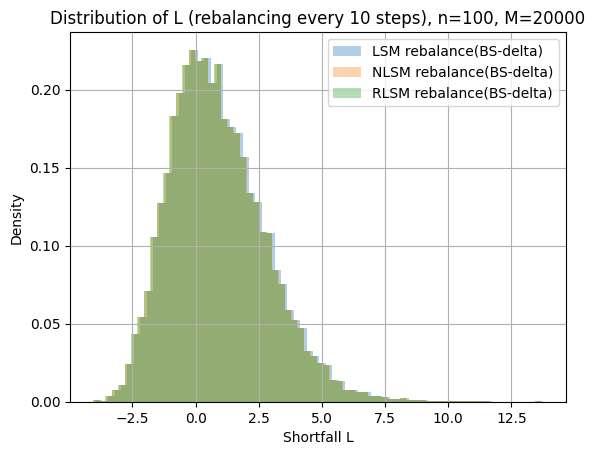

In [13]:
plt.figure()
for algo in sorted(sub["algo"].unique()):
    row = sub[sub["algo"] == algo].iloc[0]
    V0 = float(row["price"])
    d0 = float(row["delta"]) if not np.isnan(row["delta"]) else 0.0

    L_bh = shortfall_buy_and_hold(S, K, r, T, V0, d0)
    plt.hist(L_bh, bins=70, density=True, alpha=0.35, label=f"{algo} buy-hold")

plt.xlabel("Shortfall L")
plt.ylabel("Density")
plt.title(f"Distribution of L (buy-and-hold), n={N_STEPS}, M={M_HEDGE}")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for algo in sorted(sub["algo"].unique()):
    row = sub[sub["algo"] == algo].iloc[0]
    V0 = float(row["price"])

    L_rb = shortfall_rebalance_bsdelta(S, K, r, sigma, T, V0, rebalance_every=REBAL_EVERY)
    plt.hist(L_rb, bins=70, density=True, alpha=0.35, label=f"{algo} rebalance(BS-delta)")

plt.xlabel("Shortfall L")
plt.ylabel("Density")
plt.title(f"Distribution of L (rebalancing every {REBAL_EVERY} steps), n={N_STEPS}, M={M_HEDGE}")
plt.legend()
plt.grid(True)
plt.show()


,rebalance_every,VaR0.99,CVaR0.99
0,1,2.883381,3.158992
1,2,3.291338,3.663568
2,5,4.430080,5.157153
3,10,6.250227,7.434735
4,20,8.666601,10.606925
5,50,13.650072,16.948201


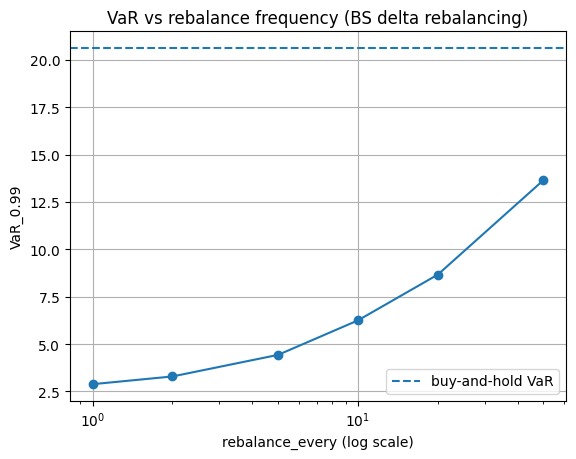

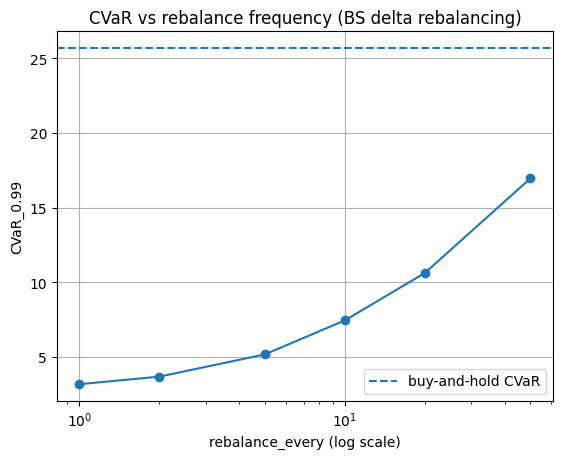

In [14]:
rebalance_grid = [1, 2, 5, 10, 20, 50]  # 1 = каждый шаг, 10 = 10 ребалансов, 50 = 2 ребаланса
algo_pick = sorted(sub["algo"].unique())[0]  # можно выбрать любой, здесь не важно

row = sub[sub["algo"] == algo_pick].iloc[0]
V0 = float(row["price"])
d0 = float(row["delta"]) if not np.isnan(row["delta"]) else 0.0

# buy-and-hold baseline
L_bh = shortfall_buy_and_hold(S, K, r, T, V0, d0)
var_bh, cvar_bh = var_cvar(L_bh, alpha=ALPHA)

rows = []
for k in rebalance_grid:
    L_rb = shortfall_rebalance_bsdelta(S, K, r, sigma, T, V0, rebalance_every=k)
    v, cv = var_cvar(L_rb, alpha=ALPHA)
    rows.append({"rebalance_every": k, f"VaR{ALPHA}": v, f"CVaR{ALPHA}": cv})

sens = pd.DataFrame(rows).sort_values("rebalance_every")
display(sens)

plt.figure()
plt.axhline(var_bh, linestyle="--", label="buy-and-hold VaR")
plt.plot(sens["rebalance_every"], sens[f"VaR{ALPHA}"], marker="o")
plt.xscale("log")
plt.xlabel("rebalance_every (log scale)")
plt.ylabel(f"VaR_{ALPHA}")
plt.title("VaR vs rebalance frequency (BS delta rebalancing)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.axhline(cvar_bh, linestyle="--", label="buy-and-hold CVaR")
plt.plot(sens["rebalance_every"], sens[f"CVaR{ALPHA}"], marker="o")
plt.xscale("log")
plt.xlabel("rebalance_every (log scale)")
plt.ylabel(f"CVaR_{ALPHA}")
plt.title("CVaR vs rebalance frequency (BS delta rebalancing)")
plt.grid(True)
plt.legend()
plt.show()
